In [1]:
# --- CELLA 1: SETUP AMBIENTE E IMPORTAZIONI ---
import sys
import os
import yaml
import h5py
import numpy as np
import scipy.io as sio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# ========== GLOBAL SEED FOR REPRODUCIBILITY ==========
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'✅ Global seed set to {SEED} for reproducibility')
# =====================================================

# 1. Aggiungi il percorso del progetto al sys.path
#    In questo modo, possiamo importare i moduli da src/
PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)

print(f'Project path: {PROJECT_PATH}')
print(f'Working dir: {os.getcwd()}')

# Verifica GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Setup completato! Stiamo usando: {device}')

✅ Global seed set to 42 for reproducibility
Project path: /media/beegfs/home/y222/y222446/SpectraBreast
Working dir: /media/beegfs/home/y222/y222446/SpectraBreast
✅ Setup completato! Stiamo usando: cpu


In [ ]:
# --- CELLA 2: LETTURA CONFIGURAZIONE E CREAZIONE SCONTRINO ---
import os
import yaml
import shutil

# Config fissa (senza fallback)
config_file = 'configs/classification/IBD/CNN/exp_01_cnn_baseline.yaml'
assert os.path.exists(config_file), f'Config non trovato: {config_file}'

# Legge il YAML
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)

# Creazione automatica cartella in experiments
output_dir = config_file.replace('configs', 'experiments').replace('.yaml', '')
os.makedirs(output_dir, exist_ok=True)

# Copia lo scontrino YAML
shutil.copy(config_file, os.path.join(output_dir, 'config_usato.yaml'))

print(f"Esperimento in esecuzione: {config['experiment_name']}")
print(f'Config usato: {config_file}')
print(f'I risultati verranno salvati in:\n{output_dir}')

Esperimento in esecuzione: exp_01_cnn_baseline
Config usato: configs/classification/IBD/CNN/exp_01_cnn_baseline.yaml
I risultati verranno salvati in:
experiments/classification/IBD/CNN/exp_01_cnn_baseline


In [3]:
# --- CELLA 3: CARICAMENTO DATI, SPLIT INDICI E DATALOADERS ---
import h5py
import scipy.io as sio
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

assert 'config' in globals(), 'Config non caricato: esegui prima la Cella 2.'
assert 'output_dir' in globals(), 'output_dir non definito: esegui prima la Cella 2.'

dataset_path = config['dataset']['path']
print(f'Caricamento dati da: {dataset_path}...')
assert os.path.exists(dataset_path), f'Dataset non trovato: {dataset_path}'

x_axis = None
try:
    with h5py.File(dataset_path, 'r') as f:
        X_data = np.array(f['X_processed'])
        Y_data = np.array(f['labels_binary']).flatten().astype(np.int64)
        # Asse spettrale (se presente nel .mat)
        for key in ('asse_target', 'x_axis', 'axis', 'wavenumbers'):
            if key in f.keys():
                x_axis = np.array(f[key]).flatten()
                break
except (OSError, NotImplementedError):
    data = sio.loadmat(dataset_path)
    X_data = data['X_processed'].astype(np.float32)
    Y_data = data['labels_binary'].flatten().astype(np.int64)
    for key in ('asse_target', 'x_axis', 'axis', 'wavenumbers'):
        if key in data:
            x_axis = np.array(data[key]).flatten()
            break

# Corregge le dimensioni per avere (Campioni, Lunghezza)
if X_data.shape[0] == 500 and X_data.shape[1] == len(Y_data):
    X_data = X_data.T

X_data = X_data.astype(np.float32)
N, L = X_data.shape

# Asse spettrale: fallback se non presente
if x_axis is None or len(x_axis) != L:
    x_axis = np.arange(L, dtype=np.float32)
else:
    x_axis = x_axis.astype(np.float32)

# Split fatto su INDICI per riproducibilità + tracciabilità nell’esperimento
idx_all = np.arange(N)
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, Y_data, test_size=0.30, random_state=SEED, stratify=Y_data
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

X_train = X_data[idx_train]
X_val = X_data[idx_val]
X_test = X_data[idx_test]

# Salva gli indici dello split nell’esperimento (per XAI / riproducibilità)
split_indices_path = os.path.join(output_dir, 'split_indices.npz')
np.savez(
    split_indices_path,
    idx_train=idx_train, idx_val=idx_val, idx_test=idx_test,
    seed=np.array([SEED], dtype=np.int64),
    dataset_path=np.array([dataset_path], dtype=object),
    input_length=np.array([L], dtype=np.int64),
    n_samples=np.array([N], dtype=np.int64),
 )
print(f'✅ Split indices salvati in: {split_indices_path}')

BATCH_SIZE = config.get('dataset', {}).get('batch_size', config.get('training', {}).get('batch_size', 32))

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train).unsqueeze(1).float(), torch.from_numpy(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val).unsqueeze(1).float(), torch.from_numpy(y_val)),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test).unsqueeze(1).float(), torch.from_numpy(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f'Spettri totali: {N}. Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}')
print(f'Batch size: {BATCH_SIZE}')
print(f'HC nel train: {(y_train==0).sum()}, IBD nel train: {(y_train==1).sum()}')

Caricamento dati da: data/IBD/Processed/IBD_Dataset_500pt.mat...
✅ Split indices salvati in: experiments/classification/IBD/CNN/exp_01_cnn_baseline/split_indices.npz
Spettri totali: 228. Train: 159, Val: 34, Test: 35
Batch size: 32
HC nel train: 65, IBD nel train: 94


In [4]:
# --- CELLA 4: COSTRUZIONE MODELLO ---
import torch.nn as nn
import torch.nn.functional as F

model_arch = config.get('model', {}).get('architecture', config.get('model', {}).get('model_type', 'RamanCNN'))

if model_arch in ['RamanCNN', 'CNN']:
    try:
        from src.models.cnn.raman_cnn_01 import RamanCNN
    except ImportError:
        from src.models.cnn.raman_cnn import RamanCNN
    print('Costruzione architettura: RamanCNN...')
    model = RamanCNN(
        input_length=config['model']['input_length'],
        n_classes=config['model']['n_classes']
    ).to(device)

elif model_arch == 'SMAE':
    print('Costruzione architettura: SMAE Classifier...')
    # model = SMAEClassifier(...).to(device)
    raise NotImplementedError('Architettura SMAE non ancora collegata in questo notebook.')
else:
    raise ValueError(f'Architettura {model_arch} non riconosciuta nel YAML!')

# Funzione per calcolare predizioni e loss in validazione/test
def evaluate_model(model, loader):
    model.eval()
    preds, labels, probs, losses = [], [], [], []
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            losses.append(criterion(logits, y_b).item())
            probs.append(F.softmax(logits, dim=1)[:, 1].cpu())
            preds.append(logits.argmax(dim=1).cpu())
            labels.append(y_b.cpu())
    return torch.cat(preds).numpy(), torch.cat(labels).numpy(), torch.cat(probs).numpy(), np.mean(losses)

Costruzione architettura: RamanCNN...


In [ ]:
# --- CELLA 5: TRAINING LOOP ---
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import torch
import os

epochs = int(config['training']['epochs'])
learning_rate = float(config['training']['learning_rate'])
weight_decay = float(config['training'].get('weight_decay', 0.0))
patience = int(config['training'].get('patience', 50)) # 50 dal config
scheduler_patience = int(config['training'].get('scheduler_patience', 7)) # 7 dal config

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# 1) Calcolo dei Class Weights (come nel tuo notebook di riferimento)
n_sano = (y_train == 0).sum()
n_ibd = (y_train == 1).sum()
weights = torch.tensor([1.0/n_sano if n_sano>0 else 0, 1.0/n_ibd if n_ibd>0 else 0], dtype=torch.float, device=device)
weights = weights / weights.sum() * 2.0

criterion = nn.CrossEntropyLoss(weight=weights)

# 2) Configurazione Learning Rate Scheduler (ReduceLROnPlateau) 
# -> factor 0.5 e patience 7
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=scheduler_patience, verbose=True)

history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}
best_f1 = -1.0
best_state = None
epochs_no_improve = 0

print(f'Inizio Training: {epochs} epoche | LR={learning_rate} | WD={weight_decay} | patience={patience}')
print(f'Class weights applicati: {weights.cpu().numpy()}')

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Valutazione
    preds_val, labels_val, probs_val, val_loss = evaluate_model(model, val_loader)
    val_f1 = f1_score(labels_val, preds_val, average='macro')
    val_acc = accuracy_score(labels_val, preds_val)

    train_loss = total_loss / max(len(train_loader), 1)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    
    # 3) Step dello scheduler basato sul f1-score di validazione
    scheduler.step(val_f1)
    
    current_lr = optimizer.param_groups[0]['lr']

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        print(f'Epoca {epoch + 1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | LR={current_lr:.2e} | BEST')
    else:
        epochs_no_improve += 1
        print(f'Epoca {epoch + 1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | LR={current_lr:.2e}')

    if epochs_no_improve >= patience:
        print(f'Early stopping attivato dopo {epoch + 1} epoche (patience={patience}).')
        break

# Salvataggio pesi migliori
if best_state is None:
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

weights_path = os.path.join(output_dir, 'best_weights.pth')
model.load_state_dict(best_state)
torch.save(model.state_dict(), weights_path)
print(f'\n✅ Training completato! Pesi migliori salvati in {weights_path}')

Inizio Training: 200 epoche | LR=0.0005 | WD=0.001 | patience=15


Epoca 001 | train_loss=0.7324 | val_loss=0.6853 | val_f1=0.3704 | BEST


Epoca 002 | train_loss=0.6885 | val_loss=0.6819 | val_f1=0.3704


Epoca 003 | train_loss=0.6163 | val_loss=0.6527 | val_f1=0.3704


Epoca 004 | train_loss=0.5914 | val_loss=0.6370 | val_f1=0.3704


...

Epoca 031 | train_loss=0.3161 | val_loss=0.3643 | val_f1=0.8712


Epoca 032 | train_loss=0.3031 | val_loss=0.4108 | val_f1=0.8068


Epoca 033 | train_loss=0.2433 | val_loss=0.4419 | val_f1=0.8419


Epoca 034 | train_loss=0.3143 | val_loss=0.5329 | val_f1=0.8755


Epoca 035 | train_loss=0.2747 | val_loss=0.3702 | val_f1=0.8755
Early stopping attivato dopo 35 epoche (patience=15).

✅ Training completato! Pesi migliori salvati in experiments/classification/IBD/CNN/exp_01_cnn_baseline/best_weights.pth



RISULTATI SUL TEST SET
Accuracy: 0.8286
Macro-F1: 0.8284
ROC-AUC: 0.9626
Test Loss: 0.3242

Classification Report:
              precision    recall  f1-score   support

      HC (0)       0.70      1.00      0.82        14
     IBD (1)       1.00      0.71      0.83        21

    accuracy                           0.83        35
   macro avg       0.85      0.86      0.83        35
weighted avg       0.88      0.83      0.83        35

✅ Manifest salvato in: experiments/classification/IBD/CNN/exp_01_cnn_baseline/manifest.json


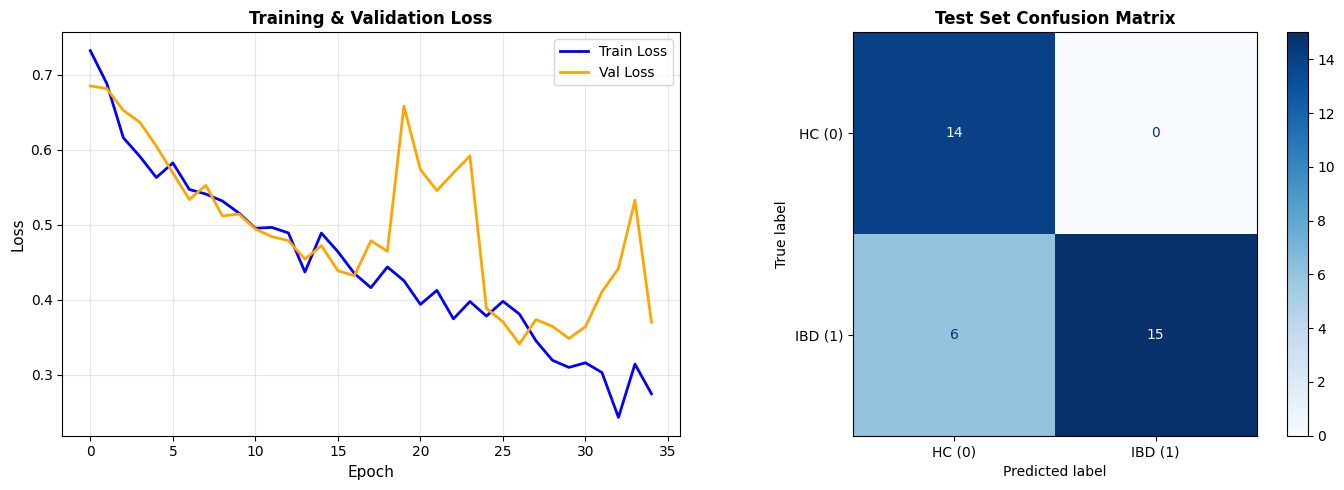

/home/y222/y222446/.local/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


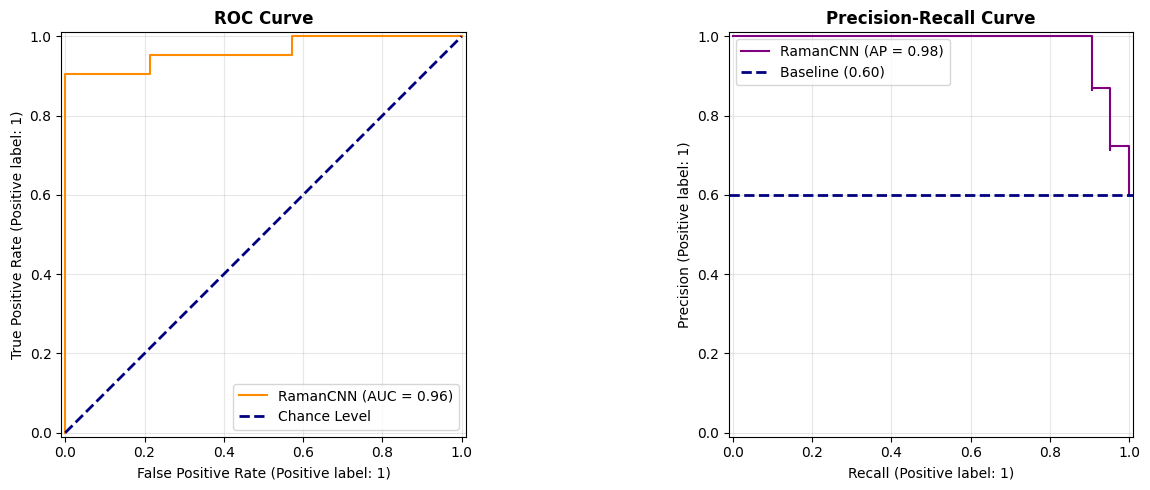

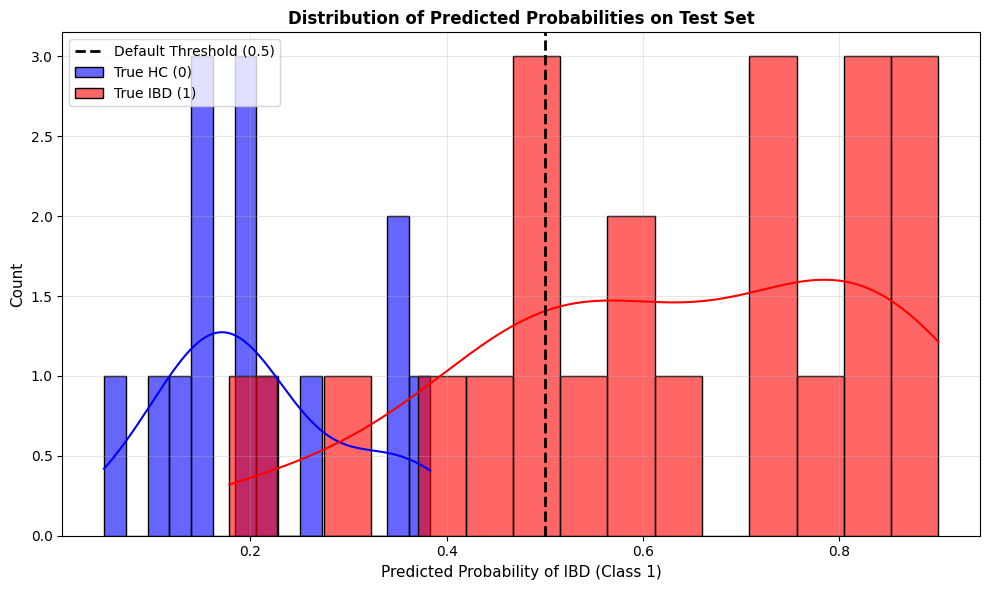


✅ Tutti i grafici sono stati salvati!



In [6]:
# --- CELLA 6: TEST SET, METRICHE E GRAFICI PROFESSIONALI ---
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, classification_report
import matplotlib.pyplot as plt
import json
import seaborn as sns
from datetime import datetime

print('\n' + '='*60)
print('RISULTATI SUL TEST SET')
print('='*60)
preds_test, labels_test, probs_test, test_loss = evaluate_model(model, test_loader)

test_acc = accuracy_score(labels_test, preds_test)
test_f1 = f1_score(labels_test, preds_test, average='macro')
test_auc = roc_auc_score(labels_test, probs_test) if len(np.unique(labels_test)) > 1 else None

print(f'Accuracy: {test_acc:.4f}')
print(f'Macro-F1: {test_f1:.4f}')
if test_auc is None:
    print('ROC-AUC: N/A (una sola classe nel test set)')
else:
    print(f'ROC-AUC: {test_auc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Salvataggio metriche in json
metrics = {
    'accuracy': float(test_acc),
    'macro_f1': float(test_f1),
    'roc_auc': float(test_auc) if test_auc is not None else 'N/A',
    'test_loss': float(test_loss),
}
metrics_path = os.path.join(output_dir, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print('\nClassification Report:')
print(classification_report(labels_test, preds_test, target_names=['HC (0)', 'IBD (1)']))

# Manifest esperimento (tracciamento unico per collegare XAI/report al run giusto)
manifest = {
    'experiment_name': str(config.get('experiment_name', 'unknown')) if isinstance(config, dict) else 'unknown',
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'seed': int(SEED) if 'SEED' in globals() else None,
    'dataset': {
        'name': config.get('dataset', {}).get('name', 'unknown') if isinstance(config, dict) else 'unknown',
        'path': config.get('dataset', {}).get('path', None) if isinstance(config, dict) else None,
    },
    'model': {
        'architecture': config.get('model', {}).get('architecture', None) if isinstance(config, dict) else None,
        'input_length': int(config.get('model', {}).get('input_length', 0)) if isinstance(config, dict) else None,
        'n_classes': int(config.get('model', {}).get('n_classes', 0)) if isinstance(config, dict) else None,
    },
    'artifacts': {
        'config_used': os.path.join(output_dir, 'config_usato.yaml'),
        'weights_best': os.path.join(output_dir, 'best_weights.pth'),
        'split_indices': os.path.join(output_dir, 'split_indices.npz'),
        'metrics': metrics_path,
        'report_html': os.path.join(output_dir, 'report_eseguito.html'),
    },
    'metrics_test': metrics,
}
manifest_path = os.path.join(output_dir, 'manifest.json')
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=4, ensure_ascii=False)
print(f'✅ Manifest salvato in: {manifest_path}')

# ========== GRAFICI PROFESSIONALI ==========
# Figura 1: Loss & Confusion Matrix (2 subplot)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax[0].plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2)
ax[0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epoch', fontsize=11)
ax[0].set_ylabel('Loss', fontsize=11)
ax[0].legend(fontsize=10)
ax[0].grid(True, alpha=0.3)

cm = confusion_matrix(labels_test, preds_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['HC (0)', 'IBD (1)'])
disp.plot(cmap='Blues', ax=ax[1], colorbar=True)
ax[1].set_title(f'Test Set Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig_loss_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

# Figura 2: ROC & Precision-Recall Curves (2 subplot)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if test_auc is not None:
    RocCurveDisplay.from_predictions(labels_test, probs_test, ax=ax[0], color='darkorange', name='RamanCNN')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=2, label='Chance Level')
    ax[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax[0].grid(alpha=0.3)
    ax[0].legend(fontsize=10)
else:
    ax[0].text(0.5, 0.5, 'N/A\n(Single Class)', ha='center', va='center', fontsize=14)
    ax[0].set_title('ROC Curve', fontsize=12, fontweight='bold')

PrecisionRecallDisplay.from_predictions(labels_test, probs_test, ax=ax[1], color='purple', name='RamanCNN')
baseline = sum(labels_test) / len(labels_test)
ax[1].axhline(baseline, color='navy', linestyle='--', linewidth=2, label=f'Baseline ({baseline:.2f})')
ax[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()

# Figura 3: Prediction Distribution Histogram (1 subplot)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(probs_test[labels_test == 0], bins=15, color='blue', alpha=0.6, label='True HC (0)', kde=True, ax=ax)
sns.histplot(probs_test[labels_test == 1], bins=15, color='red', alpha=0.6, label='True IBD (1)', kde=True, ax=ax)
ax.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
ax.set_title('Distribution of Predicted Probabilities on Test Set', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Probability of IBD (Class 1)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Tutti i grafici sono stati salvati!\n')

In [7]:
# --- CELLA 7: GENERAZIONE REPORT HTML PERSONALIZZATO ---
import base64
import json
from datetime import datetime

def img_to_base64(img_path):
    """Converte un'immagine a base64 per embeddare nell'HTML."""
    with open(img_path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

# Leggi i dati dal config e dalle metriche
with open(os.path.join(output_dir, 'config_usato.yaml'), 'r') as f:
    config_content = f.read()

with open(os.path.join(output_dir, 'metrics.json'), 'r') as f:
    metrics_data = json.load(f)

# Converti immagini a base64
img_loss_cm = img_to_base64(os.path.join(output_dir, 'fig_loss_cm.png'))
img_roc_pr = img_to_base64(os.path.join(output_dir, 'fig_roc_pr.png'))
img_dist = img_to_base64(os.path.join(output_dir, 'fig_distribution.png'))

# Estrai i parametri dal config
exp_name = config.get('experiment_name', 'Unknown')
dataset_name = config.get('dataset', {}).get('name', 'Unknown')
model_name = config.get('model', {}).get('architecture', 'Unknown')
n_epochs = config.get('training', {}).get('epochs', 'N/A')
lr = config.get('training', {}).get('learning_rate', 'N/A')
weight_decay = config.get('training', {}).get('weight_decay', 'N/A')
patience = config.get('training', {}).get('patience', 'N/A')

# Genera il timestamp
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Genera Classification Report formattato
from sklearn.metrics import classification_report
clf_report_dict = classification_report(labels_test, preds_test, target_names=['HC (0)', 'IBD (1)'], output_dict=True)

# Costruisci l'HTML
html_content = f"""
<!DOCTYPE html>
<html lang="it">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>RamanCNN Classification Report - {exp_name}</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}
        
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: #333;
            padding: 20px;
        }}
        
        .container {{
            max-width: 1200px;
            margin: 0 auto;
            background: white;
            border-radius: 12px;
            box-shadow: 0 8px 32px rgba(0, 0, 0, 0.1);
            overflow: hidden;
        }}
        
        .header {{
            background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%);
            color: white;
            padding: 40px 30px;
            text-align: center;
            border-bottom: 4px solid #667eea;
        }}
        
        .header h1 {{
            font-size: 2.5em;
            margin-bottom: 10px;
            font-weight: 700;
        }}
        
        .header p {{
            font-size: 1.1em;
            margin: 5px 0;
            opacity: 0.9;
        }}
        
        .content {{
            padding: 40px;
        }}
        
        .section {{
            margin-bottom: 40px;
        }}
        
        .section h2 {{
            color: #2c3e50;
            font-size: 1.8em;
            margin-bottom: 20px;
            padding-bottom: 10px;
            border-bottom: 3px solid #667eea;
        }}
        
        .metrics-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }}
        
        .metric-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 20px;
            border-radius: 8px;
            text-align: center;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);
            transition: transform 0.3s ease;
        }}
        
        .metric-card:hover {{
            transform: translateY(-5px);
        }}
        
        .metric-value {{
            font-size: 2.2em;
            font-weight: 700;
            margin: 10px 0;
        }}
        
        .metric-label {{
            font-size: 0.9em;
            opacity: 0.9;
            text-transform: uppercase;
            letter-spacing: 1px;
        }}
        
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            background: white;
            box-shadow: 0 2px 8px rgba(0, 0, 0, 0.05);
        }}
        
        th {{
            background: #34495e;
            color: white;
            padding: 12px;
            text-align: left;
            font-weight: 600;
        }}
        
        td {{
            padding: 12px;
            border-bottom: 1px solid #ecf0f1;
        }}
        
        tr:hover {{
            background: #f8f9fa;
        }}
        
        .code-block {{
            background: #f8f9fa;
            border-left: 4px solid #667eea;
            padding: 15px;
            margin: 15px 0;
            border-radius: 4px;
            font-family: 'Courier New', monospace;
            font-size: 0.9em;
            overflow-x: auto;
            white-space: pre-wrap;
            word-wrap: break-word;
        }}
        
        .figure {{
            margin: 30px 0;
            text-align: center;
        }}
        
        .figure img {{
            max-width: 100%;
            height: auto;
            border-radius: 8px;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);
        }}
        
        .figure-caption {{
            font-size: 0.95em;
            color: #7f8c8d;
            margin-top: 10px;
        }}
        
        .footer {{
            background: #ecf0f1;
            padding: 20px 40px;
            text-align: center;
            color: #7f8c8d;
            font-size: 0.9em;
        }}
        
        .alert {{
            background: #fff3cd;
            border-left: 4px solid #ffc107;
            padding: 15px;
            border-radius: 4px;
            margin: 20px 0;
        }}
        
        .success {{
            color: #155724;
            background-color: #d4edda;
            border-left-color: #28a745;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🧬 RamanCNN Classification Report</h1>
            <p><strong>Experiment:</strong> {exp_name}</p>
            <p><strong>Dataset:</strong> {dataset_name} (IBD vs HC Binary Classification)</p>
            <p><strong>Model:</strong> {model_name}</p>
            <p><strong>Generated:</strong> {timestamp}</p>
        </div>
        
        <div class="content">
            <!-- SEZIONE: METRICHE PRINCIPALI -->
            <div class="section">
                <h2>📊 Test Set Performance</h2>
                <div class="metrics-grid">
                    <div class="metric-card">
                        <div class="metric-label">Accuracy</div>
                        <div class="metric-value">{metrics_data['accuracy']:.4f}</div>
                    </div>
                    <div class="metric-card">
                        <div class="metric-label">Macro-F1</div>
                        <div class="metric-value">{metrics_data['macro_f1']:.4f}</div>
                    </div>
                    <div class="metric-card">
                        <div class="metric-label">ROC-AUC</div>
                        <div class="metric-value">{metrics_data['roc_auc'] if isinstance(metrics_data['roc_auc'], str) else f"{metrics_data['roc_auc']:.4f}"}</div>
                    </div>
                    <div class="metric-card">
                        <div class="metric-label">Test Loss</div>
                        <div class="metric-value">{metrics_data['test_loss']:.4f}</div>
                    </div>
                </div>
            </div>
            
            <!-- SEZIONE: CONFIGURAZIONE -->
            <div class="section">
                <h2>⚙️ Training Configuration</h2>
                <table>
                    <tr>
                        <th>Parameter</th>
                        <th>Value</th>
                    </tr>
                    <tr>
                        <td>Experiment Name</td>
                        <td>{exp_name}</td>
                    </tr>
                    <tr>
                        <td>Model Architecture</td>
                        <td>{model_name}</td>
                    </tr>
                    <tr>
                        <td>Dataset</td>
                        <td>{dataset_name}</td>
                    </tr>
                    <tr>
                        <td>Max Epochs</td>
                        <td>{n_epochs}</td>
                    </tr>
                    <tr>
                        <td>Learning Rate</td>
                        <td>{lr}</td>
                    </tr>
                    <tr>
                        <td>Weight Decay</td>
                        <td>{weight_decay}</td>
                    </tr>
                    <tr>
                        <td>Early Stopping Patience</td>
                        <td>{patience}</td>
                    </tr>
                    <tr>
                        <td>Random Seed</td>
                        <td>{SEED}</td>
                    </tr>
                </table>
            </div>
            
            <!-- SEZIONE: CLASSIFICATION REPORT -->
            <div class="section">
                <h2>📋 Classification Report</h2>
                <table>
                    <tr>
                        <th>Class</th>
                        <th>Precision</th>
                        <th>Recall</th>
                        <th>F1-Score</th>
                        <th>Support</th>
                    </tr>
                    <tr>
                        <td><strong>HC (0)</strong></td>
                        <td>{clf_report_dict['HC (0)']['precision']:.4f}</td>
                        <td>{clf_report_dict['HC (0)']['recall']:.4f}</td>
                        <td>{clf_report_dict['HC (0)']['f1-score']:.4f}</td>
                        <td>{int(clf_report_dict['HC (0)']['support'])}</td>
                    </tr>
                    <tr>
                        <td><strong>IBD (1)</strong></td>
                        <td>{clf_report_dict['IBD (1)']['precision']:.4f}</td>
                        <td>{clf_report_dict['IBD (1)']['recall']:.4f}</td>
                        <td>{clf_report_dict['IBD (1)']['f1-score']:.4f}</td>
                        <td>{int(clf_report_dict['IBD (1)']['support'])}</td>
                    </tr>
                    <tr style="background: #e8f4f8;">
                        <td><strong>Macro Avg</strong></td>
                        <td>{clf_report_dict['macro avg']['precision']:.4f}</td>
                        <td>{clf_report_dict['macro avg']['recall']:.4f}</td>
                        <td>{clf_report_dict['macro avg']['f1-score']:.4f}</td>
                        <td>{int(clf_report_dict['macro avg']['support'])}</td>
                    </tr>
                </table>
            </div>
            
            <!-- SEZIONE: VISUALIZZAZIONI -->
            <div class="section">
                <h2>📈 Results Visualization</h2>
                
                <div class="figure">
                    <img src="data:image/png;base64,{img_loss_cm}" alt="Loss and Confusion Matrix">
                    <div class="figure-caption">Figure 1: Training/Validation Loss and Test Set Confusion Matrix</div>
                </div>
                
                <div class="figure">
                    <img src="data:image/png;base64,{img_roc_pr}" alt="ROC and Precision-Recall Curves">
                    <div class="figure-caption">Figure 2: ROC Curve and Precision-Recall Curve</div>
                </div>
                
                <div class="figure">
                    <img src="data:image/png;base64,{img_dist}" alt="Prediction Distribution">
                    <div class="figure-caption">Figure 3: Distribution of Predicted Probabilities</div>
                </div>
            </div>
            
            <!-- SEZIONE: YAML CONFIG -->
            <div class="section">
                <h2>📝 YAML Configuration Used</h2>
                <div class="code-block">{config_content}</div>
            </div>
            
        </div>
        
        <div class="footer">
            <p>✅ Report generated successfully on {timestamp}</p>
            <p>Dataset: {dataset_name} | Model: {model_name} | Output Path: {output_dir}</p>
        </div>
    </div>
</body>
</html>
"""

# Salva l'HTML
report_path = os.path.join(output_dir, 'report_eseguito.html')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f'🎉 Report HTML generato con successo!')
print(f'📁 Percorso: {report_path}')

🎉 Report HTML generato con successo!
📁 Percorso: experiments/classification/IBD/CNN/exp_01_cnn_baseline/report_eseguito.html
